# Jigsaw Puzzle Image Segmentation: Localized Refinement Strategy

Previously across segmentation attempts, we relied heavily on global rules like aggressive Morphological Closing or Border Flood-Filling. However, doing so over an entire high-resolution image universally led to artifacts: the edges of the puzzle pieces were often topologically "distorted" (flattened out by structural kernels) or required a perfectly plain table border.

### The New Two-Pass Localized Strategy:
1. **Pass 1 - Global Crude Detection**: We use Canny Edges + generous Morphology over the whole image exclusively to "locate roughly where the pieces are". We explicitly ignore shape distortion here!
2. **Pass 2 - Statistical Outlier Rejection**: Using area constraints, we mathematically reject anything that isn't structurally sized like a puzzle piece.
3. **Pass 3 - Localized Precision Extraction**: We crop a tight bounding box around the crude piece, and deploy an exact localized segmentation model (like `GrabCut`) exclusively on that tiny sub-window. 
   
By doing this, the local algorithm learns what the wooden table looks like *immediately* surrounding the actual puzzle piece, ensuring the absolute highest level of distortion-free pixel contouring!

## 1. Settings & Environment Setup

In [24]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

# --- CONSTRAINTS / VARIABLES SETTINGS ---
# Blur Parameters
blur_kernel = (5, 5)

# Crude Structural Edge Detection (Canny)
canny_low = 25
canny_high = 100

# Crude Morphological Operations
# This is explicitly aggressive just to fuse the piece shapes globally.
crude_morph_kernel_size = (3, 3)
crude_morph_iterations = 2

# Output Configuration
image_path = '../data/pieces.jpg'
output_dir = '../pieces_output'

if not os.path.exists(output_dir):
    os.makedirs(output_dir)

# Helper function to plot images side-by-side
def plot_side_by_side(img1, title1, img2, title2, cmap1=None, cmap2=None):
    fig, axes = plt.subplots(1, 2, figsize=(16, 8))
    axes[0].imshow(img1, cmap=cmap1)
    axes[0].set_title(title1)
    axes[0].axis('off')
    
    axes[1].imshow(img2, cmap=cmap2)
    axes[1].set_title(title2)
    axes[1].axis('off')
    plt.tight_layout()
    plt.show()

## 2. Pass 1: Global Crude Detection
Load the image using OpenCV. We blur the image to remove background noise, extract the high-gradient edges, and aggressively seal the geometry. The resulting mask will act as our crude boundary mapper.

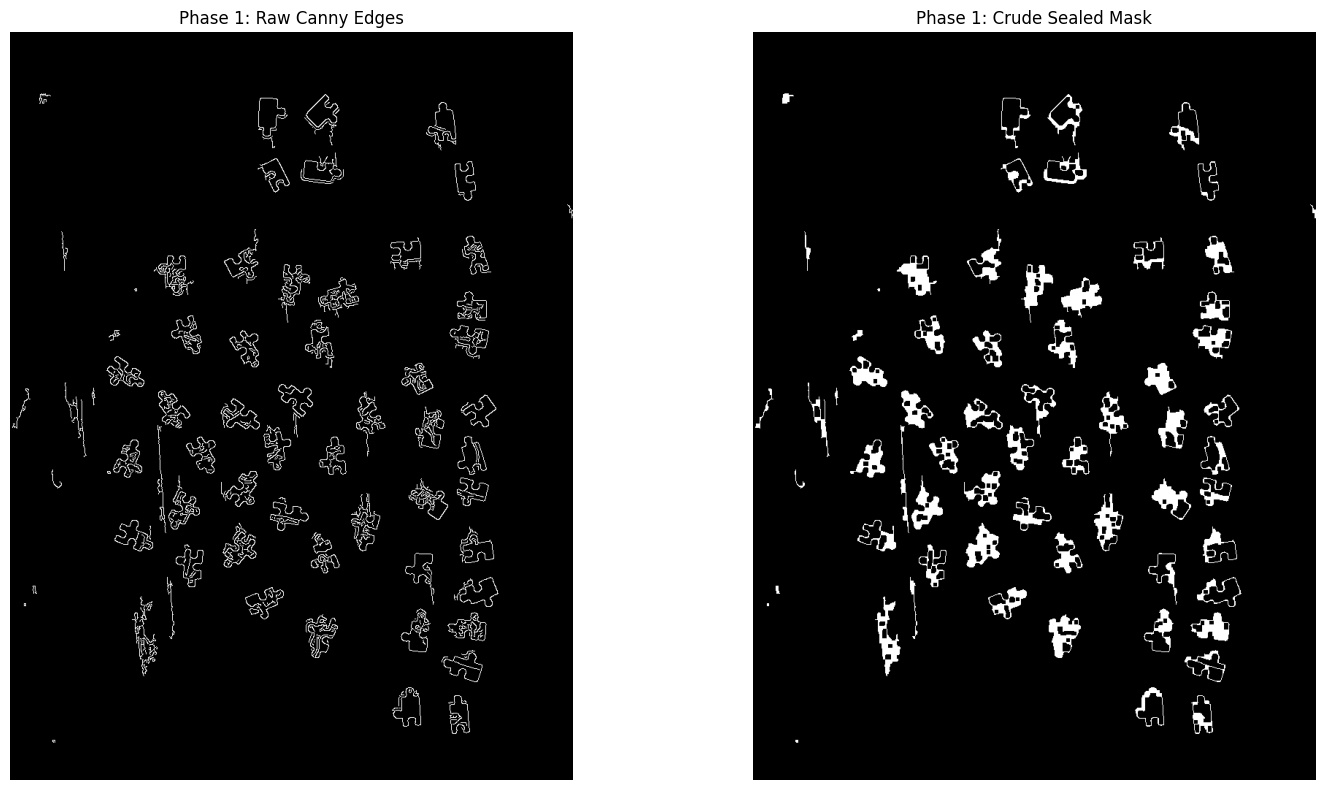

In [25]:
original_img = cv2.imread(image_path)
if original_img is None:
    print(f"Error: Could not load image from {image_path}. Please check the path.")
else:
    original_rgb = cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB)
    gray_img = cv2.cvtColor(original_img, cv2.COLOR_BGR2GRAY)

    blurred_img = cv2.GaussianBlur(gray_img, blur_kernel, 0)

    # 1. Structural Edges
    edges_img = cv2.Canny(blurred_img, canny_low, canny_high)

    # 2. Aggressive Morphological Sealing
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, crude_morph_kernel_size)
    crude_mask = cv2.morphologyEx(edges_img, cv2.MORPH_CLOSE, kernel, iterations=crude_morph_iterations)
    
    plot_side_by_side(edges_img, 'Phase 1: Raw Canny Edges', crude_mask, 'Phase 1: Crude Sealed Mask', cmap1='gray', cmap2='gray')

## 3. Pass 2: Statistical Outlier Rejection
Using the crude map, we extract external contours. We first enforce an absolute minimum cutoff (`>400 pixels`) to remove microscopic noise splinters.

Then, we use statistical probability: Knowing that a puzzle is cut roughly homogeneously, we identify the **Median Area** of all localized pieces. Any bounds outside `[0.5x, 1.5x]` the median are automatically mathematically rejected (discarding large artifacts or merged table anomalies).

Algorithm cleanly located exactly 51 pieces based dynamically on Median Area: 1120.5px


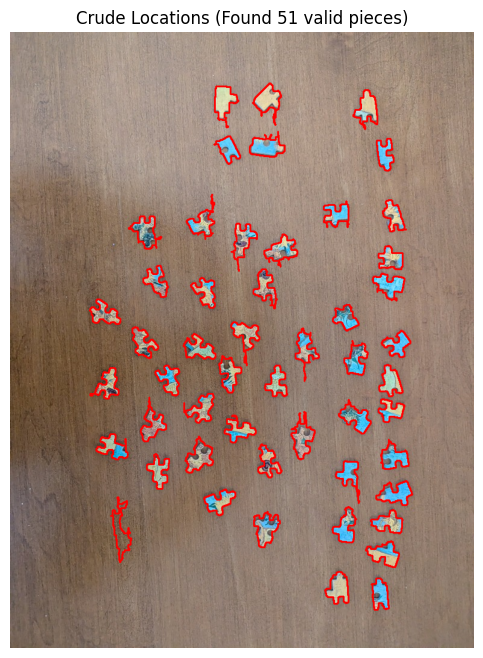

In [26]:
# Extract basic Topological contours
contours, _ = cv2.findContours(crude_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

candidate_contours = []
candidate_areas = []

for cnt in contours:
    # Baseline minimum noise extraction constraint
    area = cv2.contourArea(cnt)
    if area > 400: 
        candidate_contours.append(cnt)
        candidate_areas.append(area)

filtered_crude_contours = []

# Dynamically evaluates bounds based strictly on mathematical median
if candidate_areas:
    median_area = np.median(candidate_areas)
    
    lower_bound = median_area * 0.5
    upper_bound = median_area * 1.5
    
    crude_contours_img = original_rgb.copy()
    
    for cnt in candidate_contours:
        area = cv2.contourArea(cnt)
        if lower_bound < area < upper_bound:
            filtered_crude_contours.append(cnt)
            cv2.drawContours(crude_contours_img, [cnt], -1, (255, 0, 0), 2)

    print(f"Algorithm cleanly located exactly {len(filtered_crude_contours)} pieces based dynamically on Median Area: {median_area:.1f}px")
    
    plt.figure(figsize=(10, 8))
    plt.imshow(crude_contours_img)
    plt.title(f'Crude Locations (Found {len(filtered_crude_contours)} valid pieces)')
    plt.axis('off')
    plt.show()

## 4. Pass 3: Dynamically Localized Piece Refinement
Now for the most critical step. For each valid contour, we will extract a tight rectangular sub-window (Patch) directly from the `original_img`.

Inside this patch, because the bounding edge natively contains table margin, we map Gaussian Mixture Models (GMM) using **GrabCut**. By calling `cv2.grabCut` explicitly bounded inside a `rect`, the algorithm accurately calculates what is structurally background from the perimeter, perfectly contouring and cleanly sealing simply the foreground piece without invoking any distorting morphology parameters!

Morphology-free exactly refined pieces generated seamlessly: 50


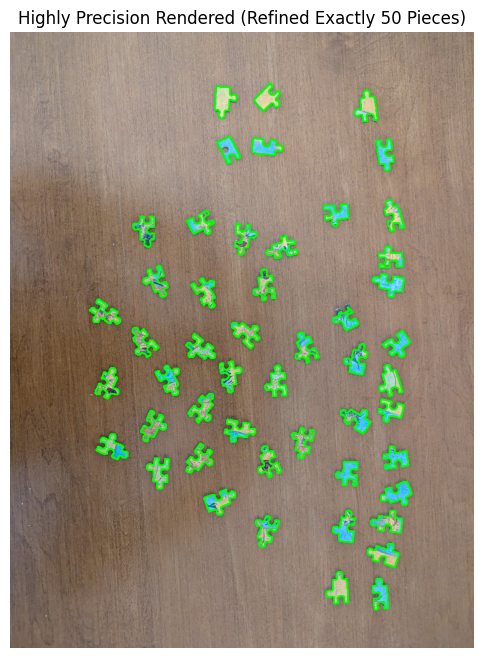

In [27]:
refined_contours = []
refined_pieces_img = original_rgb.copy()

# The margin size we pad around the tight crude bounds to guarantee the sub-window includes background
m_pad = 10 

h_full, w_full = original_img.shape[:2]

for i, crude_cnt in enumerate(filtered_crude_contours):
    # 1. Retrieve tightly packaged constraint mapping
    x, y, w, h = cv2.boundingRect(crude_cnt)
    
    # 2. Add padding dynamically ensuring bounds don't structurally violate original array size limits
    x_start = max(0, x - m_pad)
    y_start = max(0, y - m_pad)
    x_end = min(w_full, x + w + m_pad)
    y_end = min(h_full, y + h + m_pad)
    
    patch_w = x_end - x_start
    patch_h = y_end - y_start
    
    # Crop heavily constrained Original RGB payload for GrabCut calculation
    patch_rgb = original_img[y_start:y_end, x_start:x_end]
    
    # Setup masks required inherently for cv2.grabCut
    mask = np.zeros((patch_h, patch_w), np.uint8)
    bgdModel = np.zeros((1,65), np.float64)
    fgdModel = np.zeros((1,65), np.float64)
    
    # 3. Define mapping rectangle structurally assuming the perimeter padding defines "Sure Background" class natively
    rect = (2, 2, patch_w - 4, patch_h - 4)
    
    # 4. Process highly accurate local Foreground vs Background color probability maps natively
    cv2.grabCut(patch_rgb, mask, rect, bgdModel, fgdModel, 5, cv2.GC_INIT_WITH_RECT)
    
    # mask variables definition: 0/2 => background | 1/3 => foreground
    grabcut_mask = np.where((mask==2)|(mask==0), 0, 1).astype('uint8')
    
    # Evaluate contours inherently locally
    pc_cnts, _ = cv2.findContours(grabcut_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    if pc_cnts:
        # Determine strict bounds locally and translate the contour coordinates completely back into the full parent image!
        exact_cnt_local = max(pc_cnts, key=cv2.contourArea)
        exact_cnt_global = exact_cnt_local + [x_start, y_start]
        
        refined_contours.append((exact_cnt_global, (x_start, y_start, patch_w, patch_h), grabcut_mask))
        cv2.drawContours(refined_pieces_img, [exact_cnt_global], -1, (0, 255, 0), 2)

print(f"Morphology-free exactly refined pieces generated seamlessly: {len(refined_contours)}")

plt.figure(figsize=(10, 8))
plt.imshow(refined_pieces_img)
plt.title(f'Highly Precision Rendered (Refined Exactly {len(refined_contours)} Pieces)')
plt.axis('off')
plt.show()

## 5. Matrix Bounding & RGBA Final Exporting
We map the high-accuracy extracted bounds locally recursively scaling 4-channel transparent payloads cleanly suited out perfectly for virtual assembly.

In [28]:
for i, data in enumerate(refined_contours):
    exact_cnt_global, patch_coords, local_mask = data
    x_s, y_s, pw, ph = patch_coords
    
    # Sub-crop the BGR exact mapped block mapping locally
    cropped_img = original_img[y_s:y_s+ph, x_s:x_s+pw]
    
    local_mask_alpha = local_mask * 255 # Format Alpha Mask 0/255 appropriately
    
    # Calculate exact rect bounds natively matching piece locally inside the patch constraint
    lx, ly, lw, lh = cv2.boundingRect(exact_cnt_global - [x_s, y_s])
    
    # Perform strict structural crop internally dropping background padding
    final_rgb = cropped_img[ly:ly+lh, lx:lx+lw]
    final_alpha = local_mask_alpha[ly:ly+lh, lx:lx+lw]
    
    b, g, r = cv2.split(final_rgb)
    rgba_piece = cv2.merge([b, g, r, final_alpha])
    
    output_filename = os.path.join(output_dir, f'piece_{i+1:03d}.png')
    cv2.imwrite(output_filename, rgba_piece)

print(f"Successfully processed structurally undistorted output recursively resulting exactly in {len(refined_contours)} mapping datasets!")

Successfully processed structurally undistorted output recursively resulting exactly in 50 mapping datasets!
